In [19]:
import logging
import os
import joblib
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

logging.getLogger("cmdstanpy").setLevel(logging.CRITICAL)

In [20]:
df = pd.read_csv("data/new_retail_sales_augmented.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

categories = df['Product Category'].unique()
os.makedirs("models", exist_ok=True)

print(f"Kategori yang ditemukan: {categories}")
df.head()

Kategori yang ditemukan: <StringArray>
['Beauty', 'Electronics', 'Clothing']
Length: 3, dtype: str


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,AUG-20230101-BEA-0,2023-01-01,CUST-47194,Female,29,Beauty,5,142,710
1,AUG-20230101-ELE-0,2023-01-01,CUST-90038,Male,22,Electronics,1,895,895
2,AUG-20230101-BEA-1,2023-01-01,CUST-51090,Female,23,Beauty,5,136,680
3,AUG-20230101-BEA-3,2023-01-01,CUST-94478,Male,24,Beauty,1,84,84
4,AUG-20230101-BEA-4,2023-01-01,CUST-41551,Male,22,Beauty,3,148,444


In [21]:
def make_exact_holidays():
    rows = []
    
    ramadan_ranges = {
        2023: ('2023-03-22', '2023-04-20'),
        2024: ('2024-03-11', '2024-04-09'),
        2025: ('2025-03-01', '2025-03-30'),
        2026: ('2026-02-18', '2026-03-19'),
    }
    for year, (start_dt, end_dt) in ramadan_ranges.items():
        for dt in pd.date_range(start_dt, end_dt):
            rows.append({'holiday': 'ramadan_season', 'ds': dt, 'lower_window': 0, 'upper_window': 0})
            
    for year in [2023, 2024, 2025, 2026]:
        for day in range(10, 32):
            rows.append({'holiday': 'year_end_boom', 'ds': f'{year}-12-{day}', 'lower_window': 0, 'upper_window': 0})
            
        rows.append({'holiday': 'harbolnas_1111', 'ds': f'{year}-11-11', 'lower_window': -1, 'upper_window': 1})
        rows.append({'holiday': 'harbolnas_1010', 'ds': f'{year}-10-10', 'lower_window': -1, 'upper_window': 1})
        
    return pd.DataFrame(rows)

holidays_df = make_exact_holidays()
print(f"Total baris event libur terjadwal: {len(holidays_df)}")
holidays_df.sample(3)

Total baris event libur terjadwal: 216


,holiday,ds,lower_window,upper_window
183,year_end_boom,2025-12-25,0,0
22,ramadan_season,2023-04-13 00:00:00,0,0
209,year_end_boom,2026-12-27,0,0


In [22]:
def build_sales(cat_df):
    sales_raw = cat_df.copy()
    sales_raw['Date'] = pd.to_datetime(sales_raw['Date'])
    
    cat_name = sales_raw['Product Category'].iloc[0] if len(sales_raw) > 0 else 'Beauty'
    
    category_yearly_trend = {
        'Electronics': {2023: 1.00, 2024: 1.12, 2025: 0.95, 2026: 0.90},
        'Clothing':    {2023: 1.00, 2024: 1.18, 2025: 1.05, 2026: 0.92},
        'Beauty':      {2023: 1.00, 2024: 1.20, 2025: 1.10, 2026: 1.03},
    }
    
    years = sales_raw['Date'].dt.year
    trend_factors = years.map(category_yearly_trend.get(cat_name, {}))
    
    crisis_factors = np.where(sales_raw['Date'] >= '2026-01-01', 0.88,
                     np.where(sales_raw['Date'] >= '2025-07-01', 0.95, 1.0))
    
    sales_raw['macro_multiplier'] = trend_factors * crisis_factors

    # Mengubah ke mingguan sesuai kebutuhan visualisasi dashboard
    sales = sales_raw.set_index('Date').resample('W').agg({
        'Total Amount': 'sum',
        'macro_multiplier': 'mean'
    }).reset_index()
    
    sales = sales.rename(columns={'Date': 'ds', 'Total Amount': 'y'})
    sales = sales.sort_values('ds').reset_index(drop=True)
    
    return sales

In [23]:
PARAM_GRID = {
    'Beauty': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 5,
        'holidays_prior_scale': 10,
        'seasonality_mode': 'multiplicative'
    },
    'Electronics': {
        'changepoint_prior_scale': 0.01, 
        'seasonality_prior_scale': 5, 
        'holidays_prior_scale': 10,
        'seasonality_mode': 'multiplicative'
    },
    'Clothing': {
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 5,
        'holidays_prior_scale': 10,
        'seasonality_mode': 'multiplicative'
    }
}

def make_model(p):
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=holidays_df,
        seasonality_mode=p['seasonality_mode'],
        changepoint_prior_scale=p['changepoint_prior_scale'],
        seasonality_prior_scale=p['seasonality_prior_scale'],
        holidays_prior_scale=p['holidays_prior_scale'],
        interval_width=0.95
    )
    
    m.add_regressor('macro_multiplier', mode='multiplicative')
    return m

In [24]:
def train_prophet_model(category):
    print(f"\n{'━'*50}\nTraining Category: {category}")
    
    cat_df = df[df['Product Category'] == category]
    sales = build_sales(cat_df)
    params = PARAM_GRID.get(category, PARAM_GRID['Beauty'])
    
    test_weeks = 12
    train = sales.iloc[:-test_weeks]
    test = sales.iloc[-test_weeks:]
    floor_val = sales['y'].min() * 0.5
    
    # 1. Evaluasi pada Test Set
    model = make_model(params)
    model.fit(train)
    
    future_test = test[['ds', 'macro_multiplier']].copy()
    forecast = model.predict(future_test)
    
    y_true = test['y'].values
    y_pred = np.clip(forecast['yhat'].values, floor_val, None)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"Eval (12 Weeks Test Set):")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f}%")
    
    # 2. Retrain dengan semua data untuk produksi web app
    final_model = make_model(params)
    final_model.fit(sales)
    
    model_path = f"models/{category}_prophet.pkl"
    joblib.dump({'model': final_model, 'floor': floor_val}, model_path)
    print(f"Model saved successfully to: {model_path}")
    
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

In [25]:
results = {}
for cat in categories:
    results[cat] = train_prophet_model(cat)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training Category: Beauty
Eval (12 Weeks Test Set):
MAE  : 1,641.70
RMSE : 2,220.38
MAPE : 23.52%
Model saved successfully to: models/Beauty_prophet.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training Category: Electronics
Eval (12 Weeks Test Set):
MAE  : 5,921.73
RMSE : 6,955.19
MAPE : 24.30%
Model saved successfully to: models/Electronics_prophet.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training Category: Clothing
Eval (12 Weeks Test Set):
MAE  : 1,840.16
RMSE : 2,336.23
MAPE : 18.67%
Model saved successfully to: models/Clothing_prophet.pkl


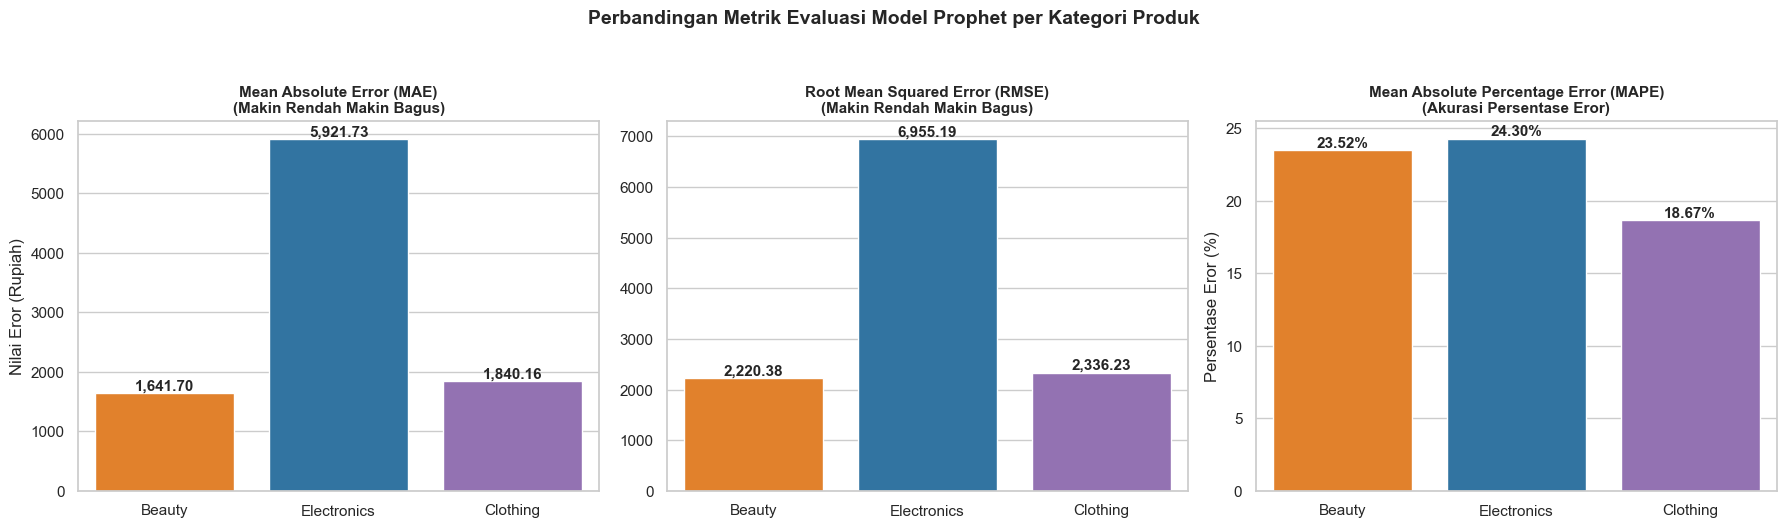

In [26]:
df_metrics = pd.DataFrame(results).T.reset_index()
df_metrics.columns = ['Category', 'MAE', 'RMSE', 'MAPE']

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Perbandingan Metrik Evaluasi Model Prophet per Kategori Produk', weight='bold', y=1.05)

colors = ['#ff7f0e', '#1f77b4', '#9467bd'] 

sns.barplot(x='Category', y='MAE', data=df_metrics, ax=axes[0], palette=colors, hue='Category', legend=False)
axes[0].set_title('Mean Absolute Error (MAE)\n(Makin Rendah Makin Bagus)', fontsize=11, weight='semibold')
axes[0].set_ylabel('Nilai Eror (Rupiah)')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():,.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

sns.barplot(x='Category', y='RMSE', data=df_metrics, ax=axes[1], palette=colors, hue='Category', legend=False)
axes[1].set_title('Root Mean Squared Error (RMSE)\n(Makin Rendah Makin Bagus)', fontsize=11, weight='semibold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():,.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

sns.barplot(x='Category', y='MAPE', data=df_metrics, ax=axes[2], palette=colors, hue='Category', legend=False)
axes[2].set_title('Mean Absolute Percentage Error (MAPE)\n(Akurasi Persentase Eror)', fontsize=11, weight='semibold')
axes[2].set_ylabel('Persentase Eror (%)')
axes[2].set_xlabel('')
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()